# Obesity Data Exploration

This notebook explores the obesity prediction dataset to understand patterns, distributions, and relationships between various features and obesity levels.

## Table of Contents
1. Data Loading
2. Initial Data Overview
3. Data Quality Assessment
4. Exploratory Data Analysis
5. Visualizations and Insights


## 1. Data Loading

First, let's import the necessary libraries and load our datasets.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the original dataset (categorical values)
df_original = pd.read_csv("../data/obesity_prediction.csv")

# Load the numeric dataset (preprocessed)
df_numeric = pd.read_csv("../data/obesity_numeric.csv", sep=';')

print("✓ Datasets loaded successfully!")
print(f"Original dataset shape: {df_original.shape}")
print(f"Numeric dataset shape: {df_numeric.shape}")


✓ Datasets loaded successfully!
Original dataset shape: (2111, 17)
Numeric dataset shape: (2111, 18)


## 2. Initial Data Overview

Let's examine the structure and first few rows of our dataset.


In [3]:
# Display first few rows
print("=== First 5 rows of the dataset ===")
df_original.head()


=== First 5 rows of the dataset ===


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
# Dataset information
print("=== Dataset Information ===")
df_original.info()


=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: fl

In [5]:
# Statistical summary for numerical features
print("=== Statistical Summary ===")
df_original.describe()


=== Statistical Summary ===


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


## 3. Data Quality Assessment

Check for missing values and understand data completeness.


In [6]:
# Check for missing values
print("=== Missing Values ===")
missing_values = df_original.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")


=== Missing Values ===
Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

Total missing values: 0


In [7]:
# Check for duplicates
duplicates = df_original.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 24


## 4. Exploratory Data Analysis

### 4.1 Understanding Categorical Variables

Let's examine the unique values and distribution of categorical features.


In [8]:
# Identify categorical columns
categorical_columns = df_original.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(categorical_columns)}\n")

# Display unique values for each categorical column
for col in categorical_columns:
    print(f"{'='*50}")
    print(f"{col}:")
    print(f"Unique values: {df_original[col].unique()}")
    print(f"Count: {df_original[col].nunique()}")
    print(f"\nValue counts:")
    print(df_original[col].value_counts())
    print()


Categorical columns: ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'Obesity']

Gender:
Unique values: ['Female' 'Male']
Count: 2

Value counts:
Gender
Male      1068
Female    1043
Name: count, dtype: int64

family_history:
Unique values: ['yes' 'no']
Count: 2

Value counts:
family_history
yes    1726
no      385
Name: count, dtype: int64

FAVC:
Unique values: ['no' 'yes']
Count: 2

Value counts:
FAVC
yes    1866
no      245
Name: count, dtype: int64

CAEC:
Unique values: ['Sometimes' 'Frequently' 'Always' 'no']
Count: 4

Value counts:
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

SMOKE:
Unique values: ['no' 'yes']
Count: 2

Value counts:
SMOKE
no     2067
yes      44
Name: count, dtype: int64

SCC:
Unique values: ['no' 'yes']
Count: 2

Value counts:
SCC
no     2015
yes      96
Name: count, dtype: int64

CALC:
Unique values: ['no' 'Sometimes' 'Frequently' 'Always']
Count: 4

Value counts:
CAL

### 4.2 Understanding Numerical Variables

Examine the distribution of numerical features.


In [9]:
# Identify numerical columns
numerical_columns = df_original.select_dtypes(include=['float64', 'int64']).columns
print(f"Numerical columns: {list(numerical_columns)}\n")

# Display summary for each numerical column
for col in numerical_columns:
    print(f"{'='*50}")
    print(f"{col}:")
    print(f"Min: {df_original[col].min():.2f}")
    print(f"Max: {df_original[col].max():.2f}")
    print(f"Mean: {df_original[col].mean():.2f}")
    print(f"Median: {df_original[col].median():.2f}")
    print(f"Std: {df_original[col].std():.2f}")
    print()


Numerical columns: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Age:
Min: 14.00
Max: 61.00
Mean: 24.31
Median: 22.78
Std: 6.35

Height:
Min: 1.45
Max: 1.98
Mean: 1.70
Median: 1.70
Std: 0.09

Weight:
Min: 39.00
Max: 173.00
Mean: 86.59
Median: 83.00
Std: 26.19

FCVC:
Min: 1.00
Max: 3.00
Mean: 2.42
Median: 2.39
Std: 0.53

NCP:
Min: 1.00
Max: 4.00
Mean: 2.69
Median: 3.00
Std: 0.78

CH2O:
Min: 1.00
Max: 3.00
Mean: 2.01
Median: 2.00
Std: 0.61

FAF:
Min: 0.00
Max: 3.00
Mean: 1.01
Median: 1.00
Std: 0.85

TUE:
Min: 0.00
Max: 2.00
Mean: 0.66
Median: 0.63
Std: 0.61



## 5. Visualizations and Insights

### 5.1 Target Variable Distribution

Understanding the distribution of obesity levels in our dataset.


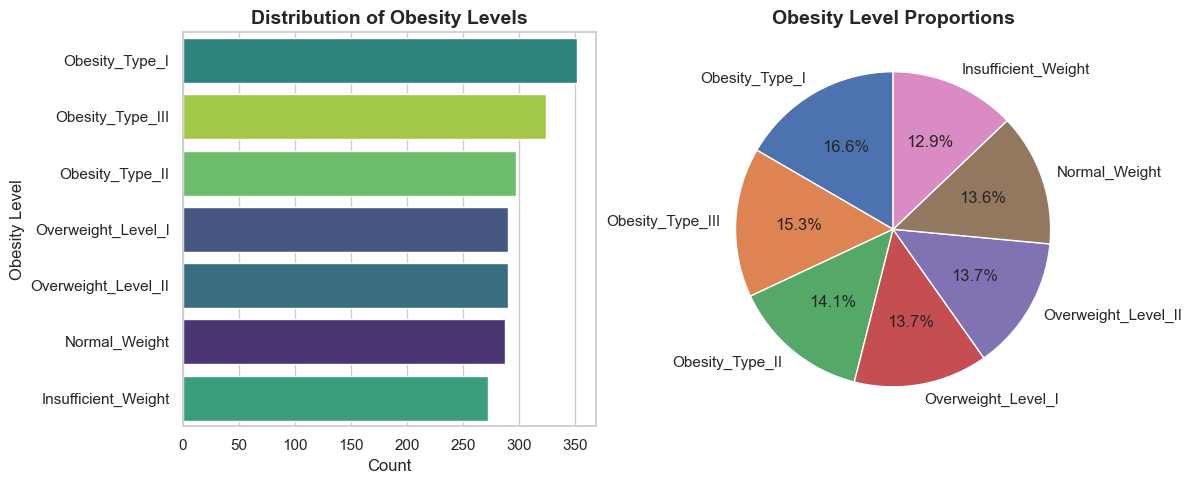


Obesity Level Distribution:
Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [10]:
# Distribution of Obesity levels
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
obesity_counts = df_original['Obesity'].value_counts()
sns.countplot(data=df_original, y='Obesity', hue='Obesity', palette='viridis', legend=False, order=obesity_counts.index)
plt.title('Distribution of Obesity Levels', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Obesity Level')

plt.subplot(1, 2, 2)
plt.pie(obesity_counts.values, labels=obesity_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Obesity Level Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nObesity Level Distribution:")
print(obesity_counts)


### 5.2 Demographic Analysis

Analyzing age and gender distribution.


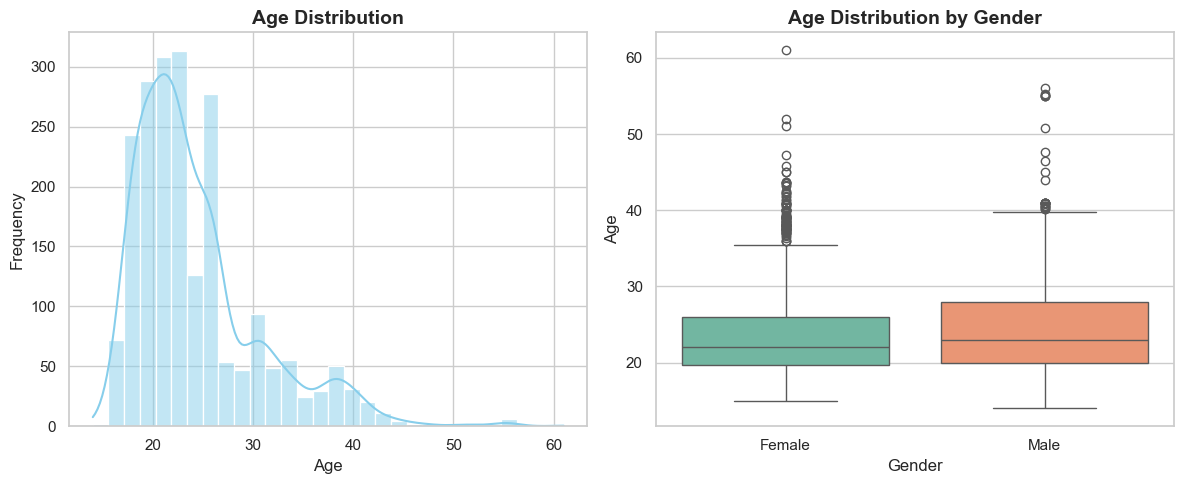

In [11]:
# Age distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_original['Age'], kde=True, bins=30, color='skyblue')
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_original, x='Gender', y='Age', hue='Gender', palette='Set2', legend=False)
plt.title('Age Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Age')

plt.tight_layout()
plt.show()


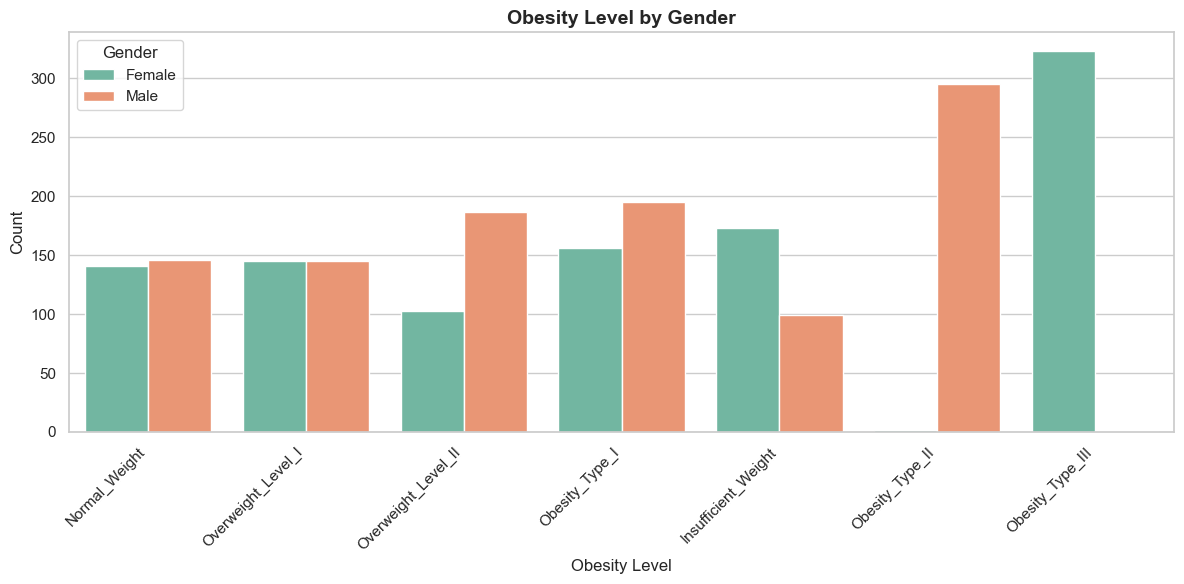

In [12]:
# Gender vs Obesity
plt.figure(figsize=(12, 6))
sns.countplot(data=df_original, x='Obesity', hue='Gender', palette='Set2')
plt.title('Obesity Level by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


### 5.3 Physical Measurements Analysis

Examining height, weight, and BMI relationships.


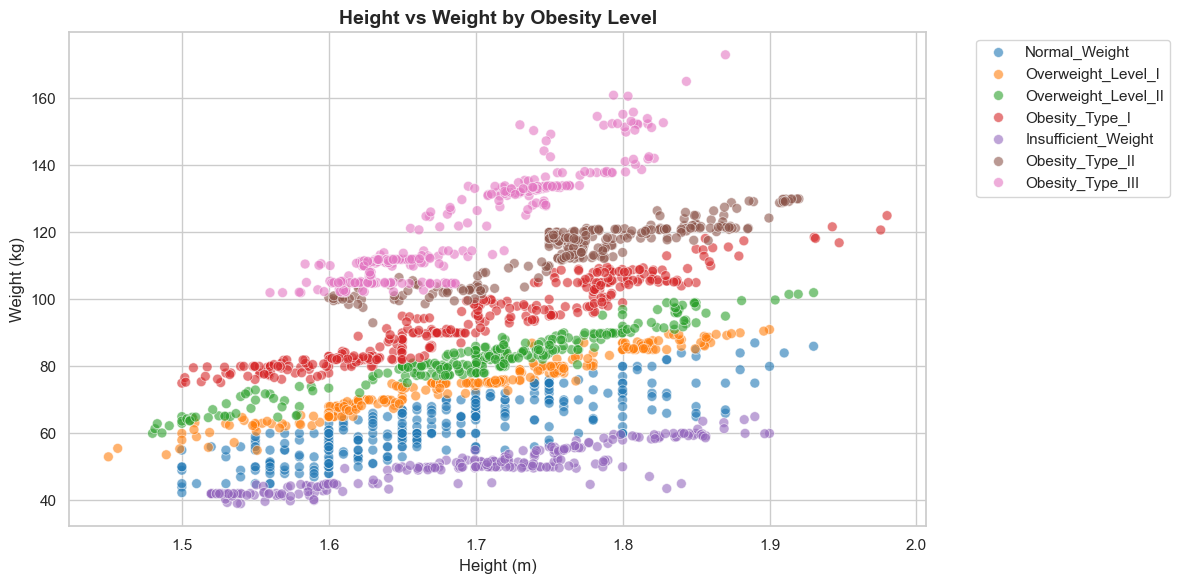

In [13]:
# Height vs Weight colored by Obesity Level
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_original, x='Height', y='Weight', hue='Obesity', 
                palette='tab10', alpha=0.6, s=50)
plt.title('Height vs Weight by Obesity Level', fontsize=14, fontweight='bold')
plt.xlabel('Height (m)')
plt.ylabel('Weight (kg)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


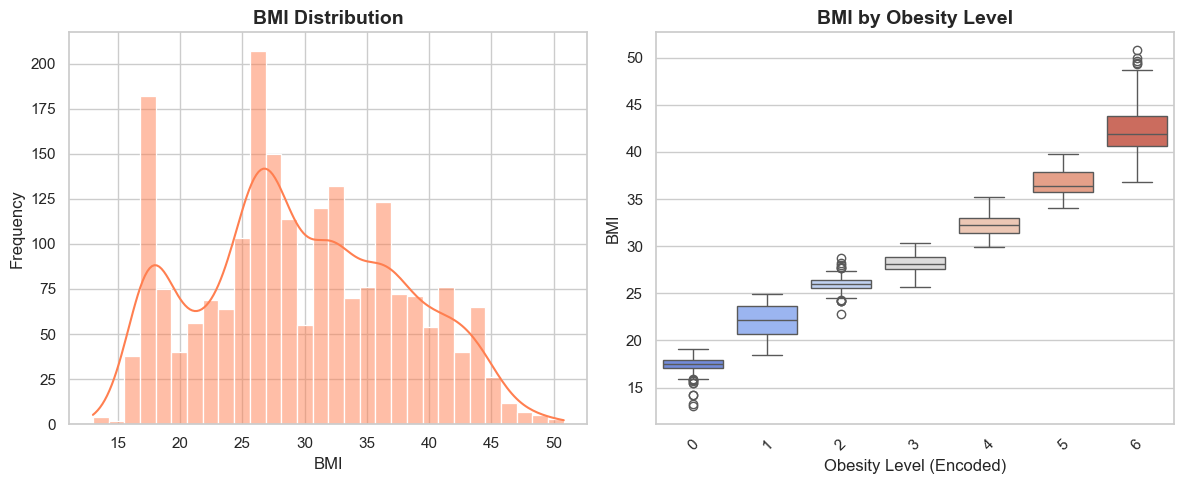

In [14]:
# BMI analysis (if available in numeric dataset)
if 'BMI' in df_numeric.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df_numeric['BMI'], kde=True, bins=30, color='coral')
    plt.title('BMI Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('BMI')
    plt.ylabel('Frequency')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_numeric, x='Obesity', y='BMI', palette='coolwarm')
    plt.title('BMI by Obesity Level', fontsize=14, fontweight='bold')
    plt.xlabel('Obesity Level (Encoded)')
    plt.ylabel('BMI')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


### 5.4 Lifestyle and Habits Analysis

Analyzing eating habits, physical activity, and other lifestyle factors.


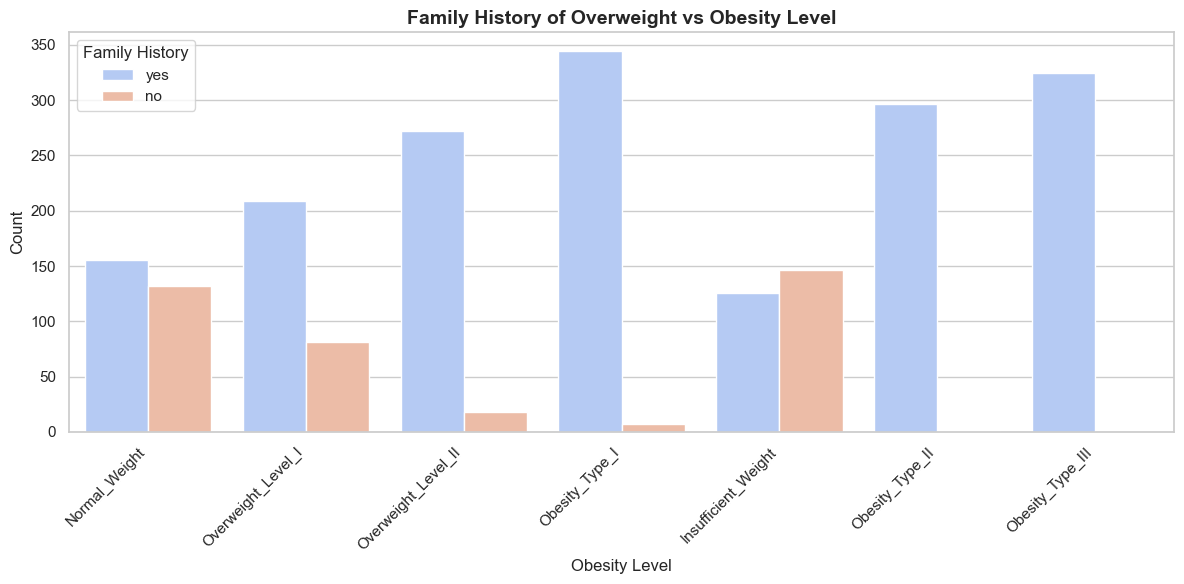

In [15]:
# Family history vs Obesity
plt.figure(figsize=(12, 6))
sns.countplot(data=df_original, x='Obesity', hue='family_history', palette='coolwarm')
plt.title('Family History of Overweight vs Obesity Level', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Family History')
plt.tight_layout()
plt.show()


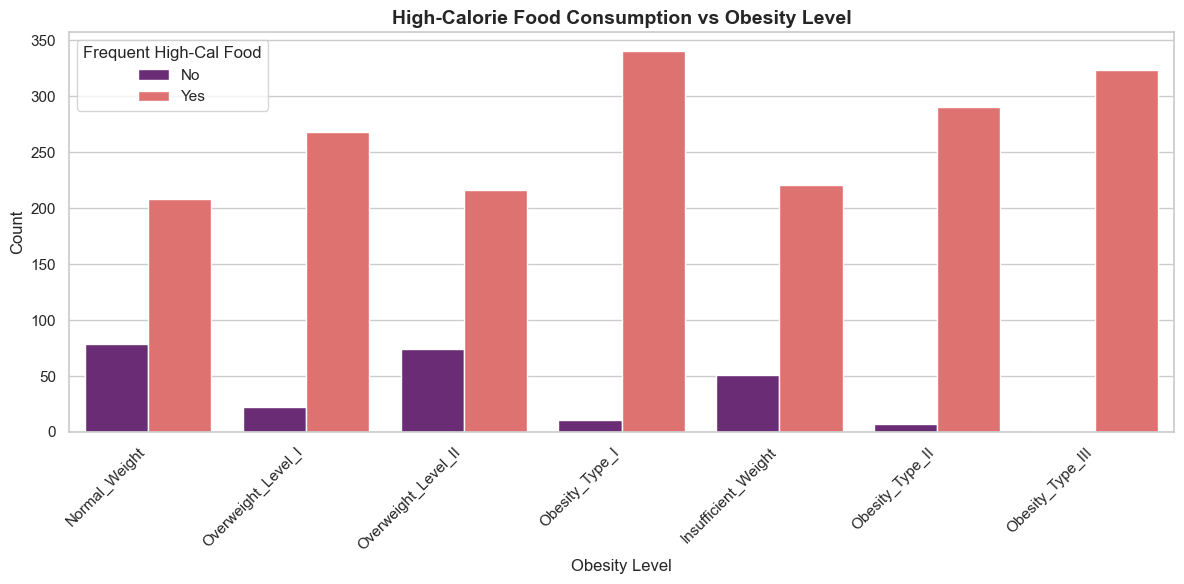

In [16]:
# High-calorie food consumption (FAVC) vs Obesity
plt.figure(figsize=(12, 6))
sns.countplot(data=df_original, x='Obesity', hue='FAVC', palette='magma')
plt.title('High-Calorie Food Consumption vs Obesity Level', fontsize=14, fontweight='bold')
plt.xlabel('Obesity Level')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Frequent High-Cal Food', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()


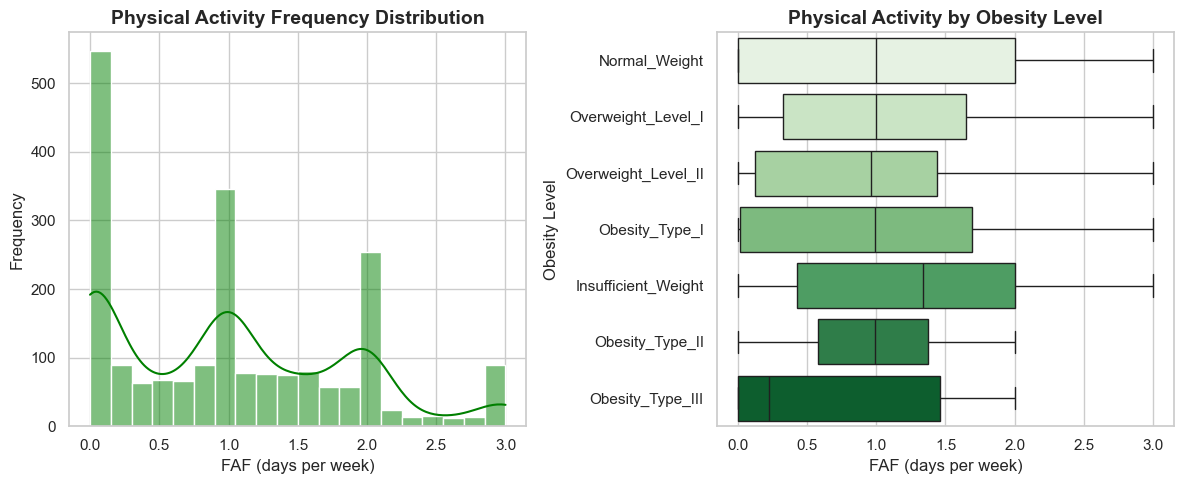

In [17]:
# Physical Activity Frequency (FAF)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_original['FAF'], kde=True, bins=20, color='green')
plt.title('Physical Activity Frequency Distribution', fontsize=14, fontweight='bold')
plt.xlabel('FAF (days per week)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_original, y='Obesity', x='FAF', palette='Greens', orient='h')
plt.title('Physical Activity by Obesity Level', fontsize=14, fontweight='bold')
plt.xlabel('FAF (days per week)')
plt.ylabel('Obesity Level')

plt.tight_layout()
plt.show()


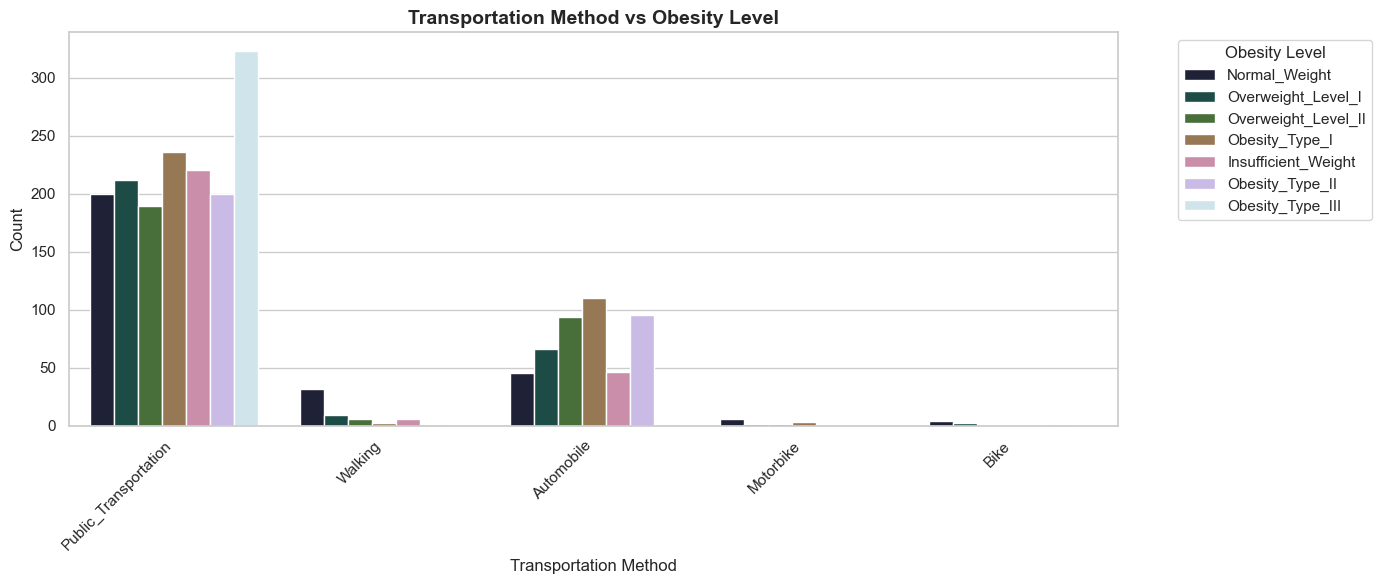

In [18]:
# Transportation method vs Obesity
plt.figure(figsize=(14, 6))
sns.countplot(data=df_original, x='MTRANS', hue='Obesity', palette='cubehelix')
plt.title('Transportation Method vs Obesity Level', fontsize=14, fontweight='bold')
plt.xlabel('Transportation Method')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 5.5 Correlation Analysis

Understanding relationships between numerical variables.


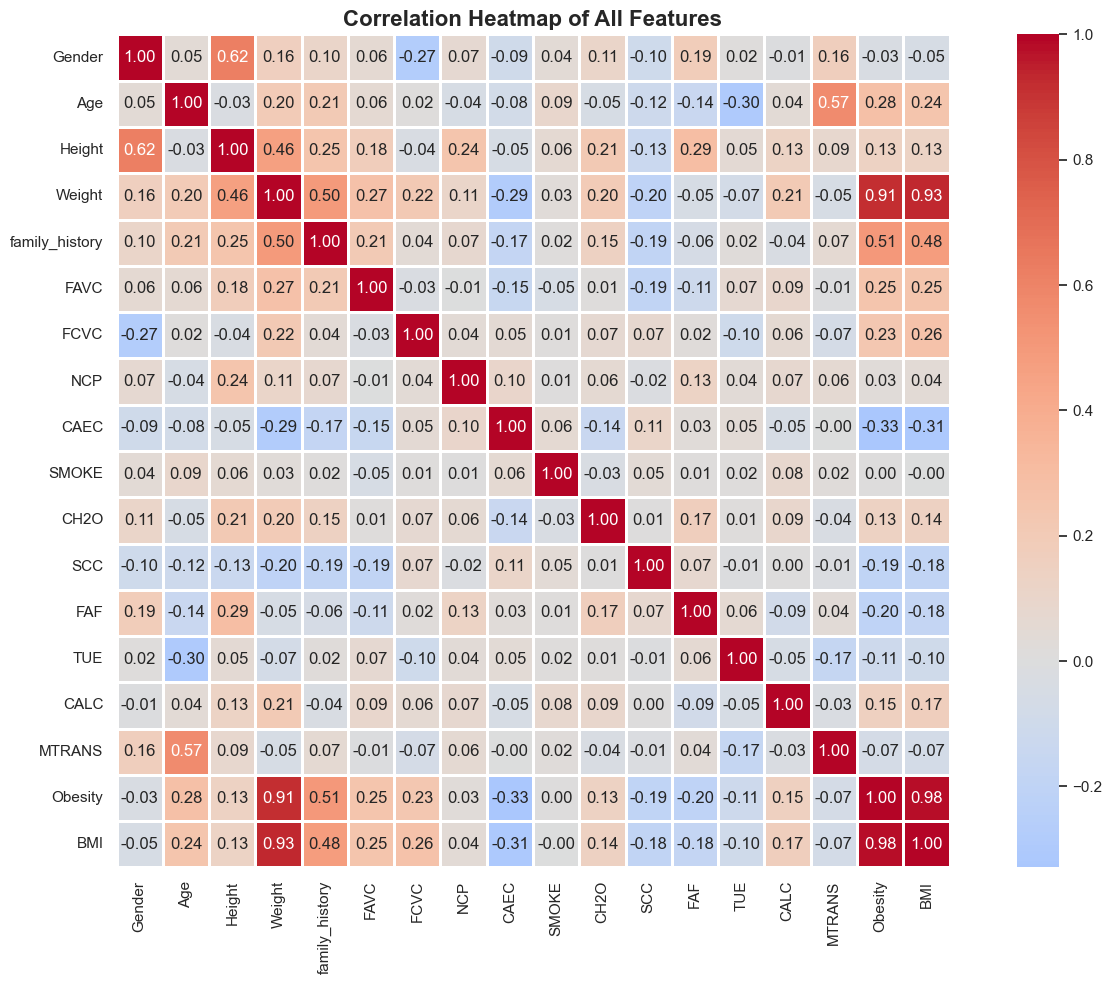

In [19]:
# Correlation heatmap for numerical features
plt.figure(figsize=(14, 10))
correlation_matrix = df_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap of All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


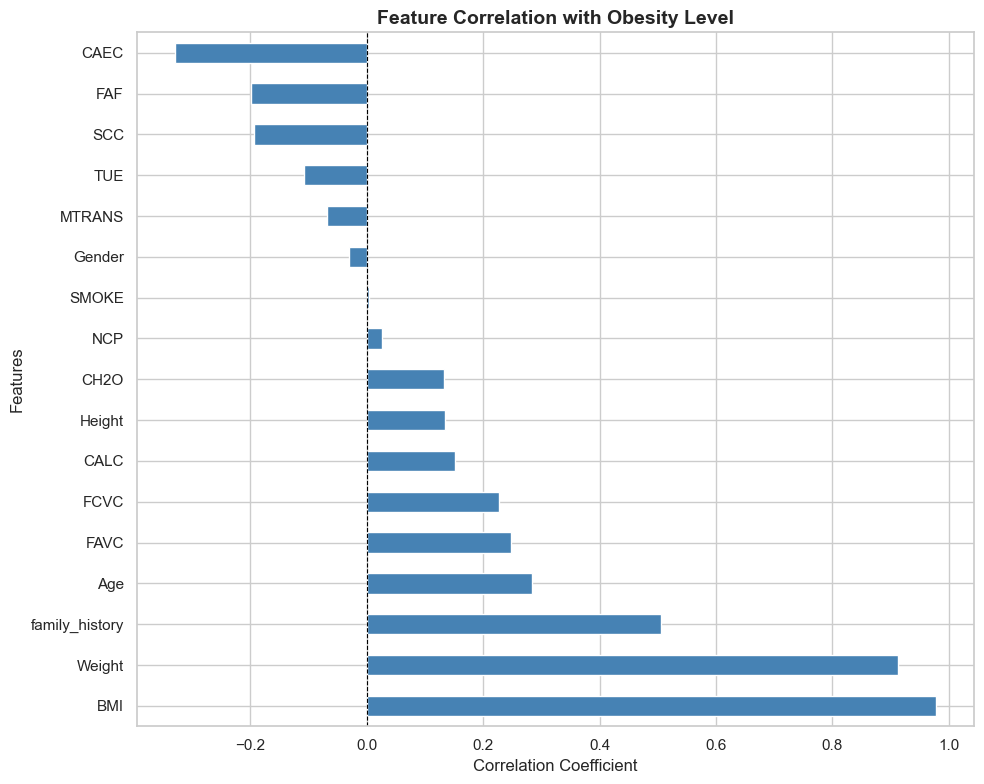


Top correlations with Obesity:
Obesity           1.000000
BMI               0.977826
Weight            0.913251
family_history    0.505148
Age               0.282913
FAVC              0.247793
FCVC              0.227759
CALC              0.151752
Height            0.133565
CH2O              0.133008
NCP               0.026690
SMOKE             0.003442
Gender           -0.031464
MTRANS           -0.067833
TUE              -0.107991
SCC              -0.194508
FAF              -0.199901
CAEC             -0.329350
Name: Obesity, dtype: float64


In [20]:
# Features most correlated with Obesity
if 'Obesity' in df_numeric.columns:
    obesity_corr = df_numeric.corr()['Obesity'].sort_values(ascending=False)
    
    plt.figure(figsize=(10, 8))
    obesity_corr[1:].plot(kind='barh', color='steelblue')
    plt.title('Feature Correlation with Obesity Level', fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Features')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()
    
    print("\nTop correlations with Obesity:")
    print(obesity_corr)


### 5.6 Additional Insights

Exploring other important features.


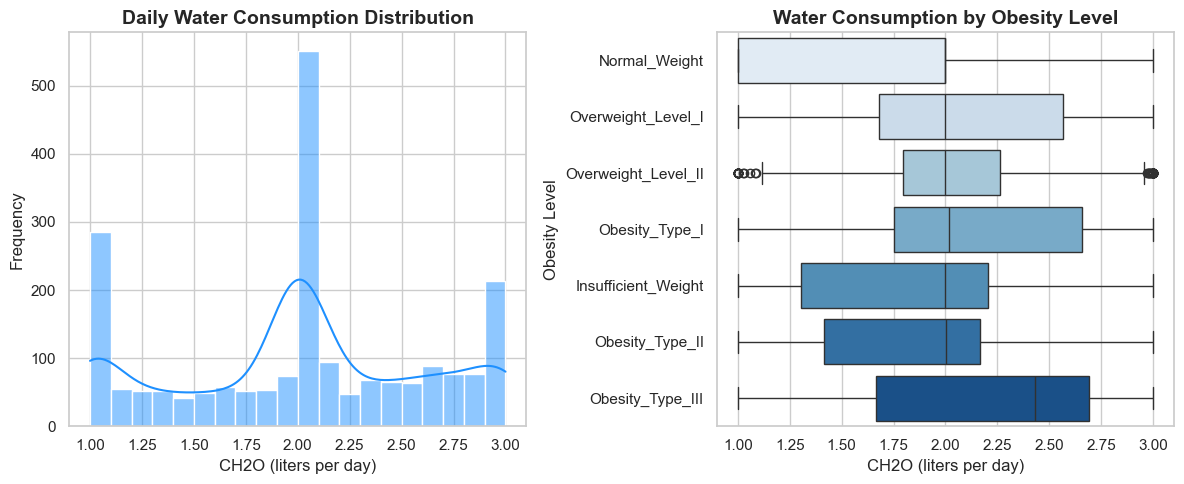

In [21]:
# Water consumption (CH2O) analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_original['CH2O'], kde=True, bins=20, color='dodgerblue')
plt.title('Daily Water Consumption Distribution', fontsize=14, fontweight='bold')
plt.xlabel('CH2O (liters per day)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_original, y='Obesity', x='CH2O', palette='Blues', orient='h')
plt.title('Water Consumption by Obesity Level', fontsize=14, fontweight='bold')
plt.xlabel('CH2O (liters per day)')
plt.ylabel('Obesity Level')

plt.tight_layout()
plt.show()


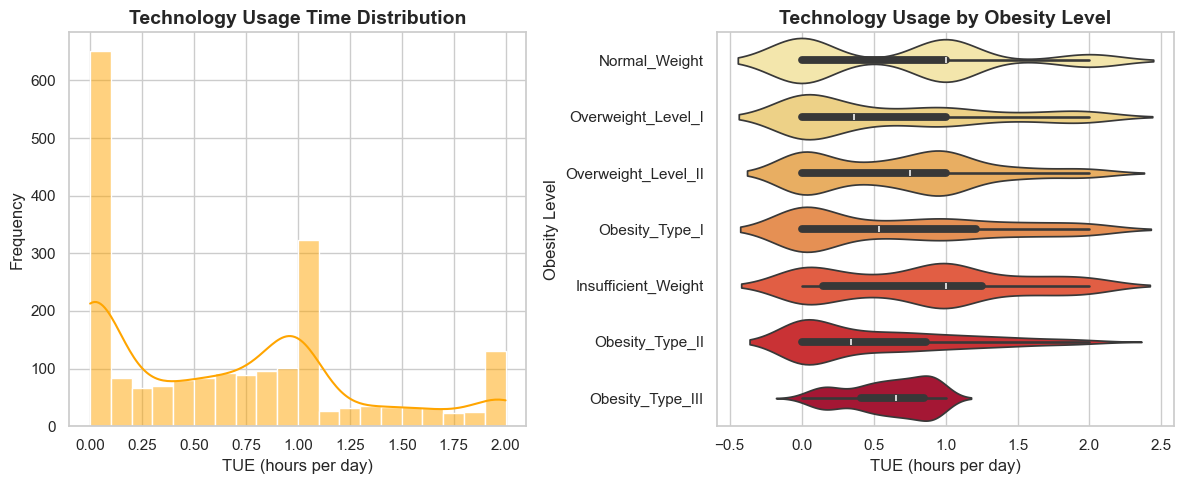

In [22]:
# Technology usage time (TUE) analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_original['TUE'], kde=True, bins=20, color='orange')
plt.title('Technology Usage Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('TUE (hours per day)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.violinplot(data=df_original, y='Obesity', x='TUE', palette='YlOrRd', orient='h')
plt.title('Technology Usage by Obesity Level', fontsize=14, fontweight='bold')
plt.xlabel('TUE (hours per day)')
plt.ylabel('Obesity Level')

plt.tight_layout()
plt.show()


## Summary of Key Findings

This section summarizes the main insights from the exploratory data analysis.


In [23]:
print("="*60)
print("KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS")
print("="*60)
print(f"\n1. Dataset Size: {df_original.shape[0]} records, {df_original.shape[1]} features")
print(f"\n2. Missing Values: {df_original.isnull().sum().sum()} (Complete dataset!)")
print(f"\n3. Obesity Level Distribution:")
for level, count in df_original['Obesity'].value_counts().items():
    print(f"   - {level}: {count} ({count/len(df_original)*100:.1f}%)")
print(f"\n4. Gender Distribution:")
for gender, count in df_original['Gender'].value_counts().items():
    print(f"   - {gender}: {count} ({count/len(df_original)*100:.1f}%)")
print(f"\n5. Age Range: {df_original['Age'].min():.0f} - {df_original['Age'].max():.0f} years (Mean: {df_original['Age'].mean():.1f})")
print(f"\n6. Family History Impact: {(df_original['family_history']=='yes').sum()} people have family history of overweight")
print(f"\n7. Physical Activity: Average {df_original['FAF'].mean():.2f} days/week")
print(f"\n8. Water Consumption: Average {df_original['CH2O'].mean():.2f} liters/day")
print("="*60)


KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS

1. Dataset Size: 2111 records, 17 features

2. Missing Values: 0 (Complete dataset!)

3. Obesity Level Distribution:
   - Obesity_Type_I: 351 (16.6%)
   - Obesity_Type_III: 324 (15.3%)
   - Obesity_Type_II: 297 (14.1%)
   - Overweight_Level_I: 290 (13.7%)
   - Overweight_Level_II: 290 (13.7%)
   - Normal_Weight: 287 (13.6%)
   - Insufficient_Weight: 272 (12.9%)

4. Gender Distribution:
   - Male: 1068 (50.6%)
   - Female: 1043 (49.4%)

5. Age Range: 14 - 61 years (Mean: 24.3)

6. Family History Impact: 1726 people have family history of overweight

7. Physical Activity: Average 1.01 days/week

8. Water Consumption: Average 2.01 liters/day
